# Result Context Extractor

## Purpose
This notebook summarizes experiment logs into publication-ready comparison tables for model configuration and group-wise generalization analysis.

## Data Sources
- `sampled_all.csv`: compact run subset used for quick configuration comparison.
- `all.csv`: full experiment log used for model and dataset-level analysis.
- `groups.csv`: merged group-level metrics for final-step ranking.

## A. Configuration Analysis on `sampled_all.csv`
This section extracts final validation metrics per run, derives configuration attributes from run names, and compares attention/embedding design choices.

**Paper usage**
- Use `main_table` for headline model ranking.
- Use `attention_mechanism_table` and `embedding_table` for ablation discussion.
- Use `feature_table` to discuss feature-wise error behavior.


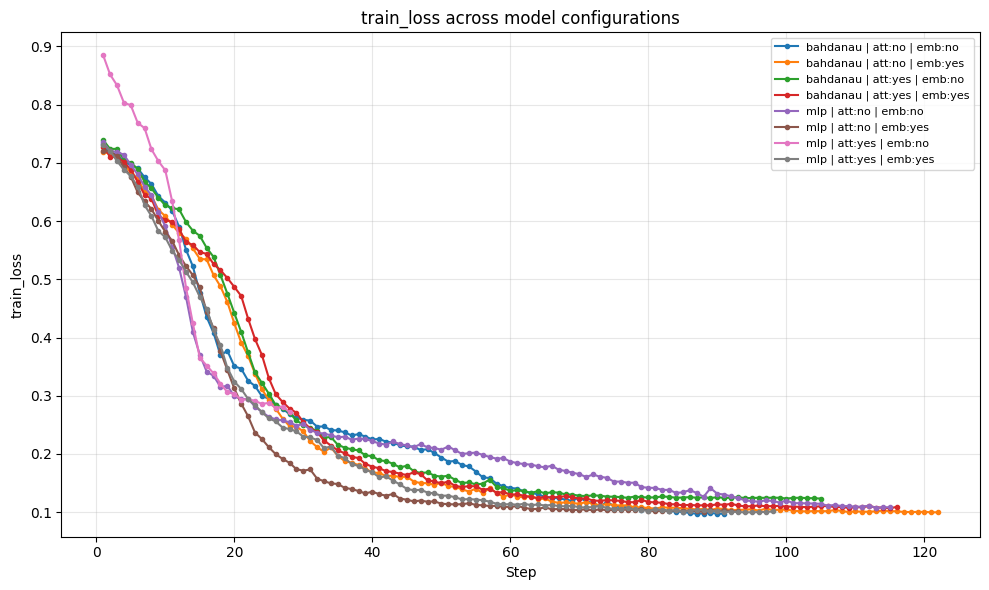

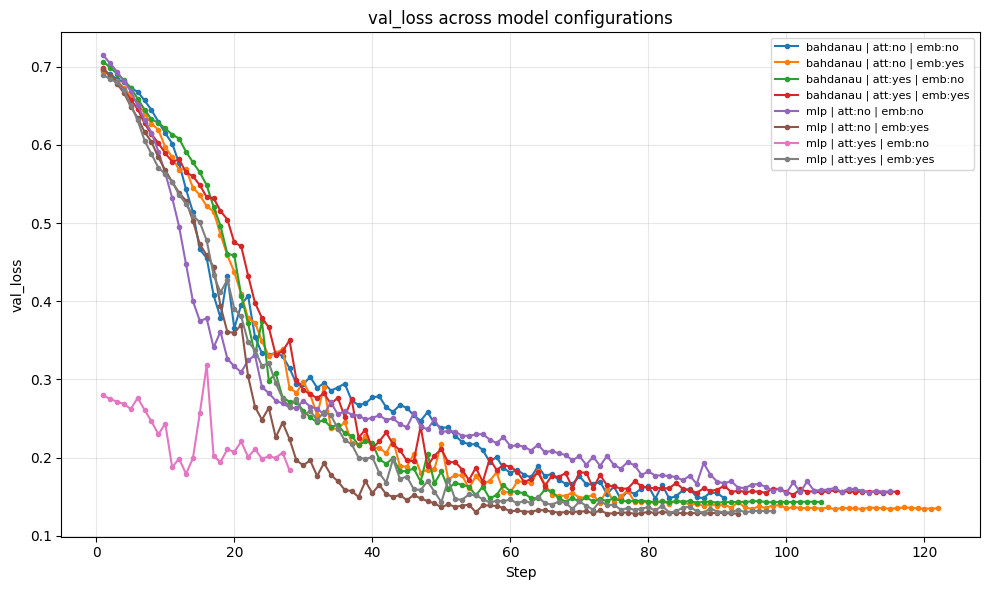

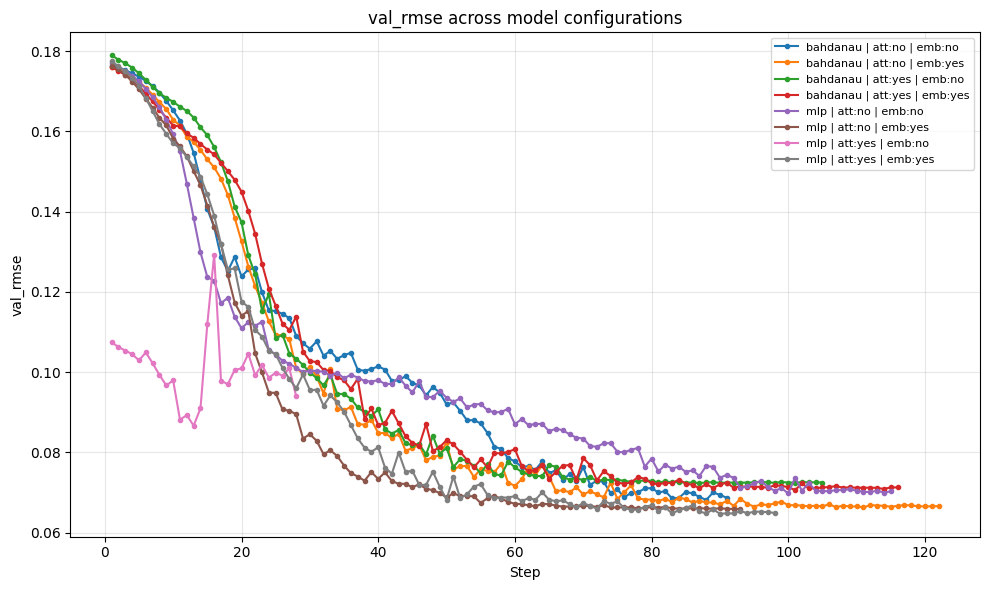

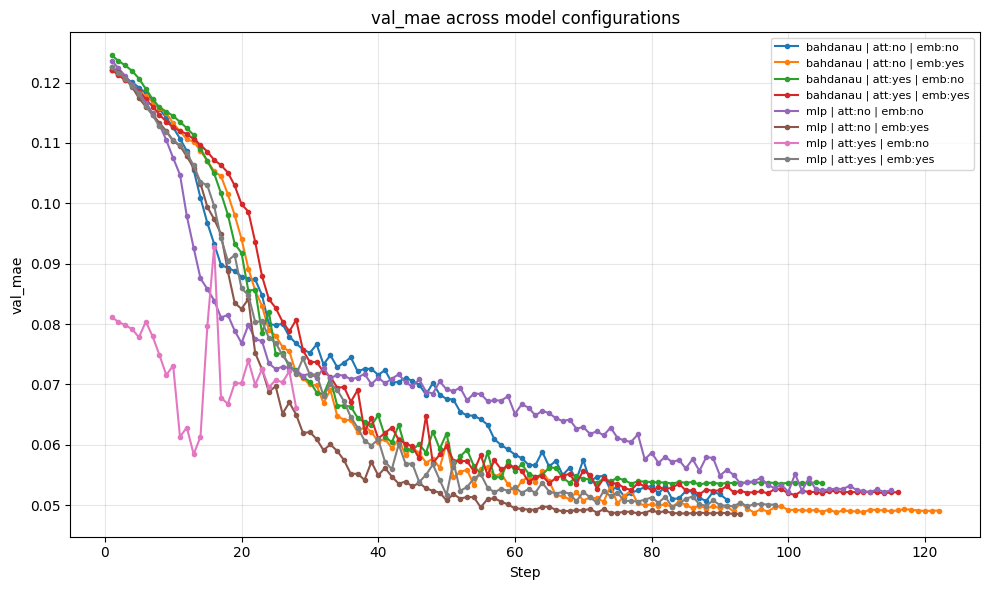

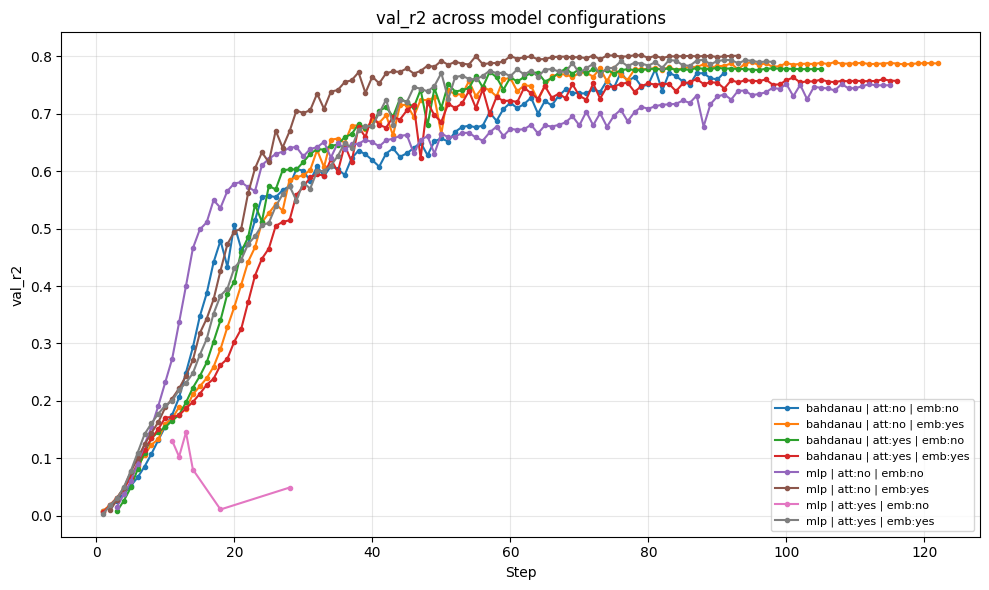

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV
df = pd.read_csv("sampled_all.csv")

# Make sure numeric columns are numeric
df["step"] = pd.to_numeric(df["step"], errors="coerce")
df["value"] = pd.to_numeric(df["value"], errors="coerce")
df["timestamp"] = pd.to_numeric(df["timestamp"], errors="coerce")

# Drop bad rows if any
df = df.dropna(subset=["metric", "Run", "step", "value"])

# Sort for clean lines
df = df.sort_values(["metric", "Run", "step"]).copy()

# Get final value per metric and run
final_values = (
    df.sort_values("step")
      .groupby(["metric", "Run"], as_index=False)
      .last()
)

# Get last step number per run
last_steps = (
    df.groupby("Run", as_index=False)["step"]
      .max()
      .rename(columns={"step": "last_step"})
)

# Pivot final metric values
table = (
    final_values.pivot(
        index="Run",
        columns="metric",
        values="value"
    )
    .reset_index()
)

table.drop(columns=["val_mbe"], inplace=True, errors="ignore")
table.columns.name = None

# Add last step into table
table = table.merge(last_steps, on="Run", how="left")

# Derive features from Run name
table["attention"] = table["Run"].str.extract(r"(yes_attention|no_attention)", expand=False)
table["embedding"] = table["Run"].str.extract(r"(yes_embedding|no_embedding)", expand=False)

table["attention_type"] = (
    table["Run"]
    .str.extract(r"(bahdanau|mlp)", expand=False)
    .fillna("none")
)

# Keep only yes / no
table["attention"] = table["attention"].str.replace("_attention", "", regex=False)
table["embedding"] = table["embedding"].str.replace("_embedding", "", regex=False)

# Fill missing values just in case
table["attention"] = table["attention"].fillna("unknown")
table["embedding"] = table["embedding"].fillna("unknown")

# Create readable configuration label
table["config"] = (
    table["attention_type"]
    + " | att:" + table["attention"]
    + " | emb:" + table["embedding"]
)

# Keep original Run for merging, store original run name separately if needed
table = table.rename(columns={"Run": "run_id"})

# Sort table
table = table.sort_values(by=["attention_type", "attention", "embedding"]).reset_index(drop=True)

# Create readable run labels
table.insert(0, "Run", [str(i + 1) for i in range(len(table))])

# Reorder columns
cols = ["Run", "run_id", "config", "attention_type", "attention", "embedding", "last_step"] + [
    c for c in table.columns
    if c not in ["Run", "run_id", "config", "attention_type", "attention", "embedding", "last_step"]
]
table = table[cols]


# -----------------------------------
# Build plotting dataframe
# -----------------------------------
run_labels = table[["run_id", "config"]].copy()

df_plot = df.merge(
    run_labels,
    left_on="Run",
    right_on="run_id",
    how="left"
)

# -----------------------------------
# Plot selected metrics across runs
# -----------------------------------
metrics = [
    "train_loss",
    "val_loss",
    "val_rmse",
    "val_mae",
    "val_r2"
]

for metric_name in metrics:
    metric_df = df_plot[df_plot["metric"] == metric_name].copy()


    plt.figure(figsize=(10, 6))

    for config, group in metric_df.groupby("config"):
        if pd.isna(config):
            continue
        group = group.sort_values("step")
        plt.plot(group["step"], group["value"], marker="o", linewidth=1.5, markersize=3, label=config)

    plt.xlabel("Step")
    plt.ylabel(metric_name)
    plt.title(f"{metric_name} across model configurations")
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

### Table: Configuration-Level Final Metrics
This table lists final-step metrics for each run in `sampled_all.csv` with decoded configuration fields and paper-ready column names.


In [2]:
import pandas as pd
# Load CSV
df = pd.read_csv("sampled_all.csv")

# Make sure numeric columns are numeric
df["step"] = pd.to_numeric(df["step"], errors="coerce")
df["value"] = pd.to_numeric(df["value"], errors="coerce")
df["timestamp"] = pd.to_numeric(df["timestamp"], errors="coerce")

# Drop bad rows if any
df = df.dropna(subset=["metric", "Run", "step", "value"])

# Sort for clean lines
df = df.sort_values(["metric", "Run", "step"])

# Get final value per metric and run
final_values = (
    df.sort_values("step")
      .groupby(["metric", "Run"])
      .last()
      .reset_index()
)

# Get last step number per run
last_steps = (
    df.groupby("Run")["step"]
      .max()
      .reset_index(name="last_step")
)

# Pivot final metric values
table = (
    final_values.pivot(
        index="Run",
        columns="metric",
        values="value"
    )
    .reset_index()
)

table.drop(columns=["val_mbe"], inplace=True, errors="ignore")
table.columns.name = None

# Add last step into table
table = table.merge(last_steps, on="Run", how="left")

# derive features from Run name
# extract attention and embedding status directly from Run
table["attention"] = table["Run"].str.extract(r'(yes_attention|no_attention)', expand=False)
table["embedding"] = table["Run"].str.extract(r'(yes_embedding|no_embedding)', expand=False)

table["attention_type"] = (
    table["Run"]
    .str.extract(r"(bahdanau|mlp)", expand=False)
    .fillna("none")
)

# keep only yes / no
table["attention"] = table["attention"].str.replace("_attention", "", regex=False)
table["embedding"] = table["embedding"].str.replace("_embedding", "", regex=False)

# rename Run → run_id
table = table.rename(columns={"Run": "run_id"})

table = table.sort_values(by="attention_type")

# create readable run labels
table.insert(0, "Run", [f"{i+1}" for i in range(len(table))])
table.drop(columns=["run_id"], inplace=True)

# reorder columns so derived columns come after run_id
cols = ["Run", "attention_type", "attention", "embedding", "last_step"] + [
    c for c in table.columns
    if c not in ["Run", "attention", "embedding", "attention_type", "last_step"]
]

table = table[cols]
table

paper_col_map = {
    "Run": "Run Number",
    "run_id": "Run Name",
    "config": "Configuration",
    "machine_part": "Machine Part",
    "model": "Model",
    "attention_type": "Attention Mechanism",
    "attention": "Feature Separated Attention",
    "embedding": "Embedding Enabled",
    "group_number": "Group ID",
    "step": "Final Step",
    "last_step": "Last Training Step",
    "train_loss": "Training Loss",
    "val_loss": "Validation Loss",
    "val_mae": "Validation MAE",
    "val_medae": "Validation MedAE",
    "val_mse": "Validation MSE",
    "val_rmse": "Validation RMSE",
    "val_r2": "Validation R2",
    "val_mse_feature_0": "Validation MSE (Feature 0)",
    "val_mse_feature_1": "Validation MSE (Feature 1)",
    "val_r2_feature_0": "Validation R2 (Feature 0)",
    "val_r2_feature_1": "Validation R2 (Feature 1)"
}

table.rename(columns=paper_col_map).T


,1,3,5,6,0,2,4,7
Run Number,1,2,3,4,5,6,7,8
Attention Mechanism,bahdanau,bahdanau,bahdanau,bahdanau,mlp,mlp,mlp,mlp
Feature Separated Attention,no,no,yes,yes,yes,no,no,yes
Embedding Enabled,no,yes,no,yes,no,no,yes,yes
Last Training Step,91,122,105,116,28,115,93,98
Training Loss,0.097196,0.099838,0.123343,0.109133,0.271748,0.108548,0.101151,0.101219
Validation Loss,0.148276,0.135291,0.143359,0.15664,0.183831,0.156962,0.128611,0.131754
Validation MAE,0.050939,0.049118,0.053694,0.052163,0.066108,0.052446,0.048578,0.050097
Validation MedAE,0.038942,0.037778,0.04273,0.040091,0.050013,0.040165,0.037676,0.042504
Validation MSE,0.004722,0.004439,0.005257,0.005079,0.008834,0.004942,0.004344,0.004215


### Table: Full Validation Summary (`sampled_all`)
This table reports the main validation metrics (`Validation Loss`, `Validation MAE`, `Validation MedAE`, `Validation MSE`, `Validation RMSE`, `Validation R2`) per run.


In [3]:
full_table = table[[
    "Run","attention_type","attention","embedding","last_step",
    "val_loss","val_mae","val_medae","val_mse","val_rmse","val_r2"
]]

full_table = full_table.rename(columns=paper_col_map)
full_table.T


,1,3,5,6,0,2,4,7
Run Number,1,2,3,4,5,6,7,8
Attention Mechanism,bahdanau,bahdanau,bahdanau,bahdanau,mlp,mlp,mlp,mlp
Feature Separated Attention,no,no,yes,yes,yes,no,no,yes
Embedding Enabled,no,yes,no,yes,no,no,yes,yes
Last Training Step,91,122,105,116,28,115,93,98
Validation Loss,0.148276,0.135291,0.143359,0.15664,0.183831,0.156962,0.128611,0.131754
Validation MAE,0.050939,0.049118,0.053694,0.052163,0.066108,0.052446,0.048578,0.050097
Validation MedAE,0.038942,0.037778,0.04273,0.040091,0.050013,0.040165,0.037676,0.042504
Validation MSE,0.004722,0.004439,0.005257,0.005079,0.008834,0.004942,0.004344,0.004215
Validation RMSE,0.068714,0.066628,0.072504,0.071266,0.093992,0.070301,0.065909,0.064921


### Table: Main Ranking by RMSE (`sampled_all`)
This table ranks configurations by `Validation RMSE` (ascending) for primary model-selection comparison.


In [4]:
main_table = table[[
    "attention_type","attention","embedding",
    "val_rmse","val_mae","val_r2",
]].sort_values("val_rmse")
main_table = main_table.rename(columns=paper_col_map)
main_table.T


,7,4,3,1,2,6,5,0
Attention Mechanism,mlp,mlp,bahdanau,bahdanau,mlp,bahdanau,bahdanau,mlp
Feature Separated Attention,yes,no,no,no,no,yes,yes,yes
Embedding Enabled,yes,yes,yes,no,no,yes,no,no
Validation RMSE,0.064921,0.065909,0.066628,0.068714,0.070301,0.071266,0.072504,0.093992
Validation MAE,0.050097,0.048578,0.049118,0.050939,0.052446,0.052163,0.053694,0.066108
Validation R2,0.790505,0.801102,0.787804,0.771814,0.749695,0.757339,0.778359,0.048844


### Table: Attention Mechanism Ablation (`sampled_all`)
This table shows mean validation performance grouped by attention mechanism type.


In [5]:
attention_mechanism_table = (
    table.groupby("attention_type")[["val_rmse","val_mae","val_r2"]]
    .mean()
    .reset_index()
)

attention_mechanism_table = attention_mechanism_table.rename(columns=paper_col_map)
attention_mechanism_table


,Attention Mechanism,Validation RMSE,Validation MAE,Validation R2
0,bahdanau,0.069778,0.051479,0.773829
1,mlp,0.073781,0.054307,0.597536


### Table: Embedding Ablation (`sampled_all`)
This table shows mean validation performance grouped by embedding usage.


In [6]:
embedding_table = (
    table.groupby("embedding")[["val_rmse","val_mae","val_r2"]]
    .mean()
    .reset_index()
)

embedding_table = embedding_table.rename(columns=paper_col_map)
embedding_table


,Embedding Enabled,Validation RMSE,Validation MAE,Validation R2
0,no,0.076378,0.055797,0.587178
1,yes,0.067181,0.049989,0.784187


### Table: Feature-Wise Error Breakdown (`sampled_all`)
This table compares total and per-feature validation MSE across configurations.


In [7]:
feature_table = table[[
    "attention_type","attention","embedding",
    "val_mse", "val_mse_feature_0","val_mse_feature_1",
    "val_r2", "val_r2_feature_0","val_r2_feature_1"
]].sort_values("val_mse")
feature_table = feature_table.rename(columns=paper_col_map)
feature_table.T


,7,4,3,1,2,6,5,0
Attention Mechanism,mlp,mlp,bahdanau,bahdanau,mlp,bahdanau,bahdanau,mlp
Feature Separated Attention,yes,no,no,no,no,yes,yes,yes
Embedding Enabled,yes,yes,yes,no,no,yes,no,no
Validation MSE,0.004215,0.004344,0.004439,0.004722,0.004942,0.005079,0.005257,0.008834
Validation MSE (Feature 0),0.002816,0.002536,0.002784,0.003014,0.003402,0.003182,0.002658,0.003151
Validation MSE (Feature 1),0.005614,0.006152,0.006095,0.006429,0.006483,0.006975,0.007856,0.014518
Validation R2,0.790505,0.801102,0.787804,0.771814,0.749695,0.757339,0.778359,0.048844
Validation R2 (Feature 0),0.685882,0.717138,0.689469,0.663724,0.620489,0.64498,0.703467,0.124499
Validation R2 (Feature 1),0.895129,0.885067,0.886139,0.879903,0.8789,0.869698,0.853252,0.056289


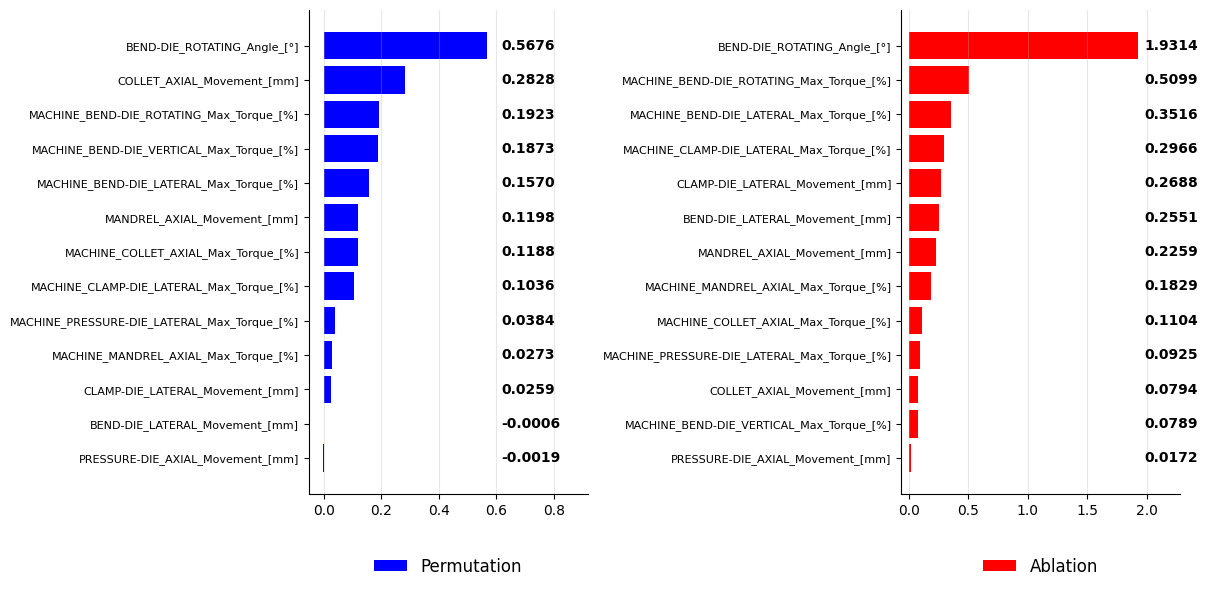

In [8]:
import matplotlib.pyplot as plt
import numpy as np


# 9f857011fcc54bd988137bcfe459c7e5
feature_importance = {
    "BEND-DIE_ROTATING_Angle_[°]": {"Permutation": 0.849914, "Ablation": 1.770788},
    "MANDREL_AXIAL_Movement_[mm]": {"Permutation": 0.552779, "Ablation": 0.683390},
    "MACHINE_BEND-DIE_LATERAL_Max_Torque_[%]": {"Permutation": 0.504407, "Ablation": 1.259121},
    "MACHINE_MANDREL_AXIAL_Max_Torque_[%]": {"Permutation": 0.308307, "Ablation": 1.432173},
    "MACHINE_COLLET_AXIAL_Max_Torque_[%]": {"Permutation": 0.270331, "Ablation": 0.349293},
    "COLLET_AXIAL_Movement_[mm]": {"Permutation": 0.238493, "Ablation": 0.143123},
    "MACHINE_BEND-DIE_ROTATING_Max_Torque_[%]": {"Permutation": 0.174452, "Ablation": 0.637867},
    "MACHINE_BEND-DIE_VERTICAL_Max_Torque_[%]": {"Permutation": 0.144834, "Ablation": 0.044960},
    "MACHINE_CLAMP-DIE_LATERAL_Max_Torque_[%]": {"Permutation": 0.017276, "Ablation": 0.048906},
    "BEND-DIE_LATERAL_Movement_[mm]": {"Permutation": 0.013105, "Ablation": 0.112185},
    "PRESSURE-DIE_AXIAL_Movement_[mm]": {"Permutation": 0.002502, "Ablation": -0.010278},
    "MACHINE_PRESSURE-DIE_LATERAL_Max_Torque_[%]": {"Permutation": -0.002121, "Ablation": 0.028796},
    "CLAMP-DIE_LATERAL_Movement_[mm]": {"Permutation": -0.007925, "Ablation": 0.018691},
}

# 25f4112799414b94ad1891d39122b9eb
feature_importance = {
    "BEND-DIE_ROTATING_Angle_[°]": {"Permutation": 0.567586, "Ablation": 1.931366},
    "COLLET_AXIAL_Movement_[mm]": {"Permutation": 0.282825, "Ablation": 0.079413},
    "MACHINE_BEND-DIE_ROTATING_Max_Torque_[%]": {"Permutation": 0.192301, "Ablation": 0.509889},
    "MACHINE_BEND-DIE_VERTICAL_Max_Torque_[%]": {"Permutation": 0.187273, "Ablation": 0.078937},
    "MACHINE_BEND-DIE_LATERAL_Max_Torque_[%]": {"Permutation": 0.156965, "Ablation": 0.351602},
    "MANDREL_AXIAL_Movement_[mm]": {"Permutation": 0.119758, "Ablation": 0.225881},
    "MACHINE_COLLET_AXIAL_Max_Torque_[%]": {"Permutation": 0.118810, "Ablation": 0.110387},
    "MACHINE_CLAMP-DIE_LATERAL_Max_Torque_[%]": {"Permutation": 0.103617, "Ablation": 0.296553},
    "MACHINE_PRESSURE-DIE_LATERAL_Max_Torque_[%]": {"Permutation": 0.038425, "Ablation": 0.092483},
    "MACHINE_MANDREL_AXIAL_Max_Torque_[%]": {"Permutation": 0.027335, "Ablation": 0.182891},
    "CLAMP-DIE_LATERAL_Movement_[mm]": {"Permutation": 0.025925, "Ablation": 0.268752},
    "BEND-DIE_LATERAL_Movement_[mm]": {"Permutation": -0.000591, "Ablation": 0.255074},
    "PRESSURE-DIE_AXIAL_Movement_[mm]": {"Permutation": -0.001918, "Ablation": 0.017186},
}

# af204c40943647c7b1dfef9b5034ad68
# feature_importance = {
#     "BEND-DIE_ROTATING_Angle_[°]": {"Permutation": 0.569127, "Ablation": 2.781229},
#     "COLLET_AXIAL_Movement_[mm]": {"Permutation": 0.348923, "Ablation": 0.133520},
#     "MACHINE_BEND-DIE_VERTICAL_Max_Torque_[%]": {"Permutation": 0.291982, "Ablation": 0.098118},
#     "MACHINE_COLLET_AXIAL_Max_Torque_[%]": {"Permutation": 0.246124, "Ablation": 0.317925},
#     "MANDREL_AXIAL_Movement_[mm]": {"Permutation": 0.193611, "Ablation": 0.196009},
#     "MACHINE_BEND-DIE_LATERAL_Max_Torque_[%]": {"Permutation": 0.108732, "Ablation": 0.395688},
#     "MACHINE_MANDREL_AXIAL_Max_Torque_[%]": {"Permutation": 0.084562, "Ablation": 1.056510},
#     "MACHINE_BEND-DIE_ROTATING_Max_Torque_[%]": {"Permutation": 0.052760, "Ablation": 0.475645},
#     "PRESSURE-DIE_AXIAL_Movement_[mm]": {"Permutation": 0.037165, "Ablation": 0.048599},
#     "MACHINE_CLAMP-DIE_LATERAL_Max_Torque_[%]": {"Permutation": 0.023070, "Ablation": 0.099548},
#     "CLAMP-DIE_LATERAL_Movement_[mm]": {"Permutation": 0.020983, "Ablation": 0.069036},
#     "BEND-DIE_LATERAL_Movement_[mm]": {"Permutation": -0.001461, "Ablation": 0.122947},
#     "MACHINE_PRESSURE-DIE_LATERAL_Max_Torque_[%]": {"Permutation": -0.008151, "Ablation": 0.032570},
# }


features = list(feature_importance.keys())
perm = np.array([feature_importance[f]["Permutation"] for f in features])
abl = np.array([feature_importance[f]["Ablation"] for f in features])

# Sort independently
perm_order = np.argsort(perm)[::-1]
abl_order = np.argsort(abl)[::-1]

perm_features = [features[i] for i in perm_order]
perm_vals = perm[perm_order]

abl_features = [features[i] for i in abl_order]
abl_vals = abl[abl_order]

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,6))

# ---- Permutation ----
y = np.arange(len(perm_features))
bars = ax1.barh(y, perm_vals, color="blue", label="Permutation")

ax1.set_yticks(y)
ax1.set_yticklabels(perm_features, fontsize=8)
ax1.invert_yaxis()
ax1.grid(axis="x", alpha=0.3)

ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

xmin, xmax = perm_vals.min(), perm_vals.max()
ax1.set_xlim(xmin-0.05, xmax+0.35)

label_x = xmax + 0.05

for i, b in enumerate(bars):
    ax1.text(label_x,
             b.get_y()+b.get_height()/2,
             f"{perm_vals[i]:.4f}",
             va="center",
             fontsize=10,
             fontweight="bold")

ax1.legend(loc="upper center",
           bbox_to_anchor=(0.5,-0.1),
           frameon=False,
           fontsize=12)

# ---- Ablation ----
y = np.arange(len(abl_features))
bars = ax2.barh(y, abl_vals, color="red", label="Ablation")

ax2.set_yticks(y)
ax2.set_yticklabels(abl_features, fontsize=8)
ax2.invert_yaxis()
ax2.grid(axis="x", alpha=0.3)

ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

xmin, xmax = abl_vals.min(), abl_vals.max()
ax2.set_xlim(xmin-0.08, xmax+0.35)

label_x = xmax + 0.05

for i, b in enumerate(bars):
    ax2.text(label_x,
             b.get_y()+b.get_height()/2,
             f"{abl_vals[i]:.4f}",
             va="center",
             fontsize=10,
             fontweight="bold")

ax2.legend(loc="upper center",
           bbox_to_anchor=(0.5,-0.1),
           frameon=False,
           fontsize=12)

plt.tight_layout()
plt.show()

## B. Full Run Analysis on `all.csv`
This section scales the same extraction logic to all runs and adds `model` and `machine_part` factors for cross-dataset/model comparisons.

**Paper usage**
- Use `main_results_df` as the complete result table.
- Use `best_per_group_df` to report best configuration per (`machine_part`, `model`).
- Use `model_comparison_df` and `dataset_comparison_df` for aggregate performance statements.


### Table: Full-Run Final Metrics (`all.csv`)
This table summarizes final-step metrics for all runs with machine part, model, and architecture options.


In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV
df = pd.read_csv("all.csv")

# Make sure numeric columns are numeric
df["step"] = pd.to_numeric(df["step"], errors="coerce")
df["value"] = pd.to_numeric(df["value"], errors="coerce")
df["timestamp"] = pd.to_numeric(df["timestamp"], errors="coerce")

# Drop bad rows if any
df = df.dropna(subset=["metric", "Run", "step", "value"])

# Sort for clean lines
df = df.sort_values(["metric", "Run", "step"])

# Get final value per metric and run
final_values = (
    df.sort_values("step")
      .groupby(["metric", "Run"])
      .last()
      .reset_index()
)

# Get last step number per run
last_steps = (
    df.groupby("Run")["step"]
      .max()
      .reset_index(name="last_step")
)

# Pivot final metric values
table = (
    final_values.pivot(
        index="Run",
        columns="metric",
        values="value"
    )
    .reset_index()
)

table.drop(columns=["val_mbe"], inplace=True, errors="ignore")
table.columns.name = None

# Add last step into table
table = table.merge(last_steps, on="Run", how="left")

# derive features from Run name
# extract attention and embedding status directly from Run
table["attention"] = table["Run"].str.extract(r"(yes_attention|no_attention)", expand=False)
table["embedding"] = table["Run"].str.extract(r"(yes_embedding|no_embedding)", expand=False)

table["attention_type"] = (
    table["Run"]
    .str.extract(r"(bahdanau|mlp)", expand=False)
    .fillna("none")
)

# extract model
# first match tcn_lstm explicitly, otherwise match lstm only if tcn_lstm is not present
table["model"] = table["Run"].str.extract(r"(tcn_lstm)", expand=False).fillna("lstm")
#table["model"]= table["Run"].str.extract(r"\b(lstm)\b", expand=False)

# extract machine part
table["machine_part"] = table["Run"].str.extract(r"^(All|Bending)", expand=False)

# keep only yes / no
table["attention"] = table["attention"].str.replace("_attention", "", regex=False)
table["embedding"] = table["embedding"].str.replace("_embedding", "", regex=False)

# fill missing values if needed
table["attention"] = table["attention"].fillna("none")
table["embedding"] = table["embedding"].fillna("none")
table["model"] = table["model"].fillna("unknown")
table["machine_part"] = table["machine_part"].fillna("unknown")
table["attention_type"] = table["attention_type"].fillna("none")

# rename Run → run_id
table = table.rename(columns={"Run": "run_id"})

table = table.sort_values(by=["machine_part", "model", "attention_type"])

# create readable run labels
table.insert(0, "Run", [f"{i+1}" for i in range(len(table))])

# reorder columns
cols = ["Run", "machine_part", "model", "attention_type", "attention", "embedding", "last_step"] + [
    c for c in table.columns
    if c not in ["Run", "machine_part", "run_id", "model", "attention", "embedding", "attention_type", "last_step"]
]

table = table[cols]

table

paper_col_map = {
    "Run": "Run Number",
    "run_id": "Run Name",
    "config": "Configuration",
    "machine_part": "Machine Part",
    "model": "Model",
    "attention_type": "Attention Mechanism",
    "attention": "Feature Separated Attention",
    "embedding": "Embedding Enabled",
    "group_number": "Group ID",
    "step": "Final Step",
    "last_step": "Last Training Step",
    "train_loss": "Training Loss",
    "val_loss": "Validation Loss",
    "val_mae": "Validation MAE",
    "val_medae": "Validation MedAE",
    "val_mse": "Validation MSE",
    "val_rmse": "Validation RMSE",
    "val_r2": "Validation R2",
    "val_mse_feature_0": "Validation MSE (Feature 0)",
    "val_mse_feature_1": "Validation MSE (Feature 1)",
    "val_r2_feature_0": "Validation R2 (Feature 0)",
    "val_r2_feature_1": "Validation R2 (Feature 1)"
}

table.rename(columns=paper_col_map)


,Run Number,Machine Part,Model,Attention Mechanism,Feature Separated Attention,Embedding Enabled,Last Training Step,Training Loss,Validation Loss,Validation MAE,Validation MedAE,Validation MSE,Validation MSE (Feature 0),Validation MSE (Feature 1),Validation R2,Validation R2 (Feature 0),Validation R2 (Feature 1),Validation RMSE
0,1,All,tcn_lstm,bahdanau,no,no,97,0.146418,0.194684,0.058564,0.046163,0.006251,0.004052,0.008449,0.695063,0.547965,0.842161,0.079061
1,2,All,tcn_lstm,bahdanau,no,yes,44,0.101744,0.163332,0.053402,0.042193,0.005107,0.003424,0.006789,0.745604,0.618039,0.873169,0.071461
2,3,All,tcn_lstm,bahdanau,yes,no,73,0.122160,0.162473,0.057430,0.046270,0.005913,0.002910,0.008916,0.754421,0.675393,0.833450,0.076894
3,4,All,tcn_lstm,bahdanau,yes,yes,63,0.099653,0.135836,0.049394,0.040090,0.004261,0.003000,0.005522,0.781104,0.665365,0.896844,0.065275
4,5,All,tcn_lstm,mlp,no,no,83,0.140515,0.179865,0.060373,0.047922,0.006363,0.003483,0.009243,0.719377,0.611420,0.827334,0.079769
5,6,All,tcn_lstm,mlp,no,yes,83,0.083507,0.126406,0.046421,0.036542,0.003903,0.002831,0.004975,0.795629,0.684191,0.907068,0.062473
6,7,All,tcn_lstm,mlp,yes,no,54,0.123849,0.173686,0.059288,0.048198,0.005994,0.003568,0.008421,0.722349,0.602003,0.842695,0.077422
7,8,All,tcn_lstm,mlp,yes,yes,65,0.093802,0.169707,0.056592,0.046424,0.005534,0.003469,0.007598,0.735524,0.612983,0.858066,0.074388
8,9,Bending,lstm,bahdanau,no,no,134,0.075360,0.121710,0.046503,0.036879,0.003858,0.002620,0.005095,0.806244,0.707669,0.904820,0.062111
9,10,Bending,lstm,bahdanau,no,yes,122,0.075193,0.119522,0.046223,0.036243,0.003838,0.002618,0.005058,0.806705,0.707889,0.905520,0.061952


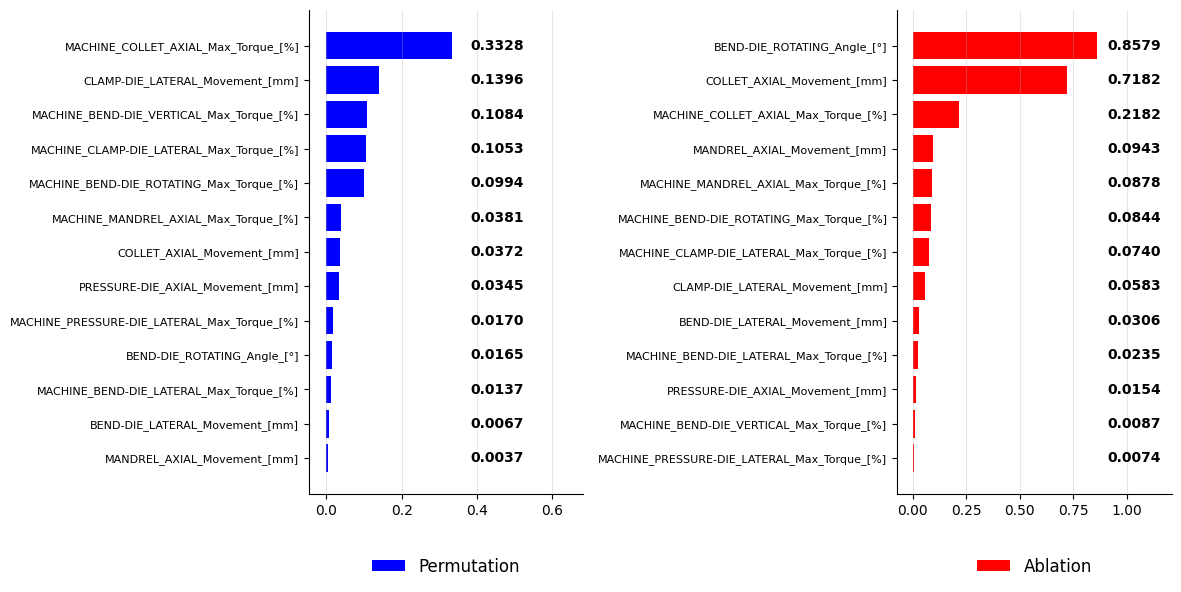

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# 8ecd70f401c845779e58e60c40729ff6
feature_importance = {
    "MACHINE_COLLET_AXIAL_Max_Torque_[%]": {"Permutation": 0.215117, "Ablation": 0.230693},
    "MACHINE_BEND-DIE_LATERAL_Max_Torque_[%]": {"Permutation": 0.174370, "Ablation": 0.357060},
    "MACHINE_BEND-DIE_VERTICAL_Max_Torque_[%]": {"Permutation": 0.094947, "Ablation": 0.024263},
    "MACHINE_MANDREL_AXIAL_Max_Torque_[%]": {"Permutation": 0.065125, "Ablation": 0.692939},
    "MACHINE_BEND-DIE_ROTATING_Max_Torque_[%]": {"Permutation": 0.044651, "Ablation": 0.251384},
    "MACHINE_CLAMP-DIE_LATERAL_Max_Torque_[%]": {"Permutation": 0.017154, "Ablation": 0.174077},
    "COLLET_AXIAL_Movement_[mm]": {"Permutation": 0.017122, "Ablation": 0.011355},
    "MANDREL_AXIAL_Movement_[mm]": {"Permutation": 0.008957, "Ablation": 0.009556},
    "BEND-DIE_ROTATING_Angle_[°]": {"Permutation": 0.005240, "Ablation": 0.120436},
    "CLAMP-DIE_LATERAL_Movement_[mm]": {"Permutation": 0.004907, "Ablation": 0.063273},
    "MACHINE_PRESSURE-DIE_LATERAL_Max_Torque_[%]": {"Permutation": 0.001474, "Ablation": 0.009187},
    "BEND-DIE_LATERAL_Movement_[mm]": {"Permutation": 0.000474, "Ablation": 0.028491},
    "PRESSURE-DIE_AXIAL_Movement_[mm]": {"Permutation": -0.000183, "Ablation": -0.019591},
}


# a116ded8d403424489c23809a916fbd2
feature_importance = {
    "MACHINE_COLLET_AXIAL_Max_Torque_[%]": {"Permutation": 0.193949, "Ablation": 0.174656},
    "MACHINE_CLAMP-DIE_LATERAL_Max_Torque_[%]": {"Permutation": 0.123821, "Ablation": 0.072595},
    "COLLET_AXIAL_Movement_[mm]": {"Permutation": 0.110009, "Ablation": 1.116292},
    "MACHINE_BEND-DIE_LATERAL_Max_Torque_[%]": {"Permutation": 0.096116, "Ablation": 0.086353},
    "MACHINE_BEND-DIE_VERTICAL_Max_Torque_[%]": {"Permutation": 0.066102, "Ablation": 0.026008},
    "MANDREL_AXIAL_Movement_[mm]": {"Permutation": 0.045372, "Ablation": 0.407571},
    "BEND-DIE_ROTATING_Angle_[°]": {"Permutation": 0.039255, "Ablation": 0.738046},
    "CLAMP-DIE_LATERAL_Movement_[mm]": {"Permutation": 0.035330, "Ablation": 0.009034},
    "MACHINE_BEND-DIE_ROTATING_Max_Torque_[%]": {"Permutation": 0.030514, "Ablation": 0.021625},
    "MACHINE_MANDREL_AXIAL_Max_Torque_[%]": {"Permutation": 0.006439, "Ablation": 0.022822},
    "MACHINE_PRESSURE-DIE_LATERAL_Max_Torque_[%]": {"Permutation": 0.005258, "Ablation": 0.002313},
    "BEND-DIE_LATERAL_Movement_[mm]": {"Permutation": 0.003881, "Ablation": 0.017475},
    "PRESSURE-DIE_AXIAL_Movement_[mm]": {"Permutation": 0.000164, "Ablation": -0.002595},
}

# 490b5f6dbf914f94aa33b82a0b4f671e
feature_importance = {
    "MACHINE_COLLET_AXIAL_Max_Torque_[%]": {"Permutation": 0.332767, "Ablation": 0.218170},
    "CLAMP-DIE_LATERAL_Movement_[mm]": {"Permutation": 0.139643, "Ablation": 0.058256},
    "MACHINE_BEND-DIE_VERTICAL_Max_Torque_[%]": {"Permutation": 0.108428, "Ablation": 0.008672},
    "MACHINE_CLAMP-DIE_LATERAL_Max_Torque_[%]": {"Permutation": 0.105303, "Ablation": 0.073971},
    "MACHINE_BEND-DIE_ROTATING_Max_Torque_[%]": {"Permutation": 0.099351, "Ablation": 0.084445},
    "MACHINE_MANDREL_AXIAL_Max_Torque_[%]": {"Permutation": 0.038090, "Ablation": 0.087847},
    "COLLET_AXIAL_Movement_[mm]": {"Permutation": 0.037193, "Ablation": 0.718185},
    "PRESSURE-DIE_AXIAL_Movement_[mm]": {"Permutation": 0.034514, "Ablation": 0.015354},
    "MACHINE_PRESSURE-DIE_LATERAL_Max_Torque_[%]": {"Permutation": 0.016976, "Ablation": 0.007427},
    "BEND-DIE_ROTATING_Angle_[°]": {"Permutation": 0.016504, "Ablation": 0.857910},
    "MACHINE_BEND-DIE_LATERAL_Max_Torque_[%]": {"Permutation": 0.013668, "Ablation": 0.023528},
    "BEND-DIE_LATERAL_Movement_[mm]": {"Permutation": 0.006683, "Ablation": 0.030586},
    "MANDREL_AXIAL_Movement_[mm]": {"Permutation": 0.003686, "Ablation": 0.094258},
}


features = list(feature_importance.keys())
perm = np.array([feature_importance[f]["Permutation"] for f in features])
abl = np.array([feature_importance[f]["Ablation"] for f in features])

# Sort independently
perm_order = np.argsort(perm)[::-1]
abl_order = np.argsort(abl)[::-1]

perm_features = [features[i] for i in perm_order]
perm_vals = perm[perm_order]

abl_features = [features[i] for i in abl_order]
abl_vals = abl[abl_order]

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,6))

# ---- Permutation ----
y = np.arange(len(perm_features))
bars = ax1.barh(y, perm_vals, color="blue", label="Permutation")

ax1.set_yticks(y)
ax1.set_yticklabels(perm_features, fontsize=8)
ax1.invert_yaxis()
ax1.grid(axis="x", alpha=0.3)

ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

xmin, xmax = perm_vals.min(), perm_vals.max()
ax1.set_xlim(xmin-0.05, xmax+0.35)

label_x = xmax + 0.05

for i, b in enumerate(bars):
    ax1.text(label_x,
             b.get_y()+b.get_height()/2,
             f"{perm_vals[i]:.4f}",
             va="center",
             fontsize=10,
             fontweight="bold")

ax1.legend(loc="upper center",
           bbox_to_anchor=(0.5,-0.1),
           frameon=False,
           fontsize=12)

# ---- Ablation ----
y = np.arange(len(abl_features))
bars = ax2.barh(y, abl_vals, color="red", label="Ablation")

ax2.set_yticks(y)
ax2.set_yticklabels(abl_features, fontsize=8)
ax2.invert_yaxis()
ax2.grid(axis="x", alpha=0.3)

ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

xmin, xmax = abl_vals.min(), abl_vals.max()
ax2.set_xlim(xmin-0.08, xmax+0.35)

label_x = xmax + 0.05

for i, b in enumerate(bars):
    ax2.text(label_x,
             b.get_y()+b.get_height()/2,
             f"{abl_vals[i]:.4f}",
             va="center",
             fontsize=10,
             fontweight="bold")

ax2.legend(loc="upper center",
           bbox_to_anchor=(0.5,-0.1),
           frameon=False,
           fontsize=12)

plt.tight_layout()
plt.show()

### Table: Main Results by Dataset and Model
This table reports per-run core metrics grouped by machine part and model family.


In [11]:
main_results_df = table[[
    "machine_part",
    "model",
    "attention_type",
    "attention",
    "embedding",
    "val_rmse",
    "val_mae",
    "val_r2"
]].sort_values(["machine_part","model","val_rmse"])

main_results_df = main_results_df.rename(columns=paper_col_map)
main_results_df


,Machine Part,Model,Attention Mechanism,Feature Separated Attention,Embedding Enabled,Validation RMSE,Validation MAE,Validation R2
5,All,tcn_lstm,mlp,no,yes,0.062473,0.046421,0.795629
3,All,tcn_lstm,bahdanau,yes,yes,0.065275,0.049394,0.781104
1,All,tcn_lstm,bahdanau,no,yes,0.071461,0.053402,0.745604
7,All,tcn_lstm,mlp,yes,yes,0.074388,0.056592,0.735524
2,All,tcn_lstm,bahdanau,yes,no,0.076894,0.057430,0.754421
6,All,tcn_lstm,mlp,yes,no,0.077422,0.059288,0.722349
0,All,tcn_lstm,bahdanau,no,no,0.079061,0.058564,0.695063
4,All,tcn_lstm,mlp,no,no,0.079769,0.060373,0.719377
11,Bending,lstm,bahdanau,yes,yes,0.058029,0.043407,0.823285
15,Bending,lstm,mlp,yes,yes,0.058526,0.044211,0.820370


### Table: Best Configuration per (`Machine Part`, `Model`)
This table selects the run with minimum `Validation RMSE` within each machine-part/model subgroup.


In [12]:
best_per_group_df = (
    table.loc[
        table.groupby(["machine_part","model"])["val_rmse"].idxmin()
    ][[
        "machine_part",
        "model",
        "attention_type",
        "attention",
        "embedding",
        "val_rmse",
        "val_mae",
        "val_r2"
    ]]
)

best_per_group_df = best_per_group_df.rename(columns=paper_col_map)
best_per_group_df


,Machine Part,Model,Attention Mechanism,Feature Separated Attention,Embedding Enabled,Validation RMSE,Validation MAE,Validation R2
5,All,tcn_lstm,mlp,no,yes,0.062473,0.046421,0.795629
11,Bending,lstm,bahdanau,yes,yes,0.058029,0.043407,0.823285
19,Bending,tcn_lstm,bahdanau,yes,yes,0.061779,0.046518,0.816842


### Table: Average Effect of Embedding (`all.csv`)
This table reports mean validation metrics aggregated by embedding usage.


In [13]:
embedding_effect_df = (
    table.groupby("embedding")[["val_rmse","val_mae","val_r2"]]
    .mean()
    .reset_index()
)

embedding_effect_df = embedding_effect_df.rename(columns=paper_col_map)
embedding_effect_df


,Embedding Enabled,Validation RMSE,Validation MAE,Validation R2
0,no,0.072248,0.054463,0.764325
1,yes,0.063847,0.048041,0.794523


### Table: Average Effect of Attention Mechanism (`all.csv`)
This table reports mean validation metrics aggregated by attention mechanism type.


In [14]:
attention_mechanism_df = (
    table.groupby("attention_type")[["val_rmse","val_mae","val_r2"]]
    .mean()
    .reset_index()
)

attention_mechanism_df = attention_mechanism_df.rename(columns=paper_col_map)
attention_mechanism_df


,Attention Mechanism,Validation RMSE,Validation MAE,Validation R2
0,bahdanau,0.067820,0.050933,0.780613
1,mlp,0.068274,0.051572,0.778235


### Table: Model Comparison by Machine Part
This table reports average validation metrics for each (`Machine Part`, `Model`) pair.


In [15]:
model_comparison_df = (
    table.groupby(["machine_part","model"])[["val_rmse","val_mae","val_r2"]]
    .mean()
    .reset_index()
)

model_comparison_df = model_comparison_df.rename(columns=paper_col_map)
model_comparison_df


,Machine Part,Model,Validation RMSE,Validation MAE,Validation R2
0,All,tcn_lstm,0.073343,0.055183,0.743634
1,Bending,lstm,0.063283,0.047506,0.804299
2,Bending,tcn_lstm,0.067516,0.051067,0.790339


### Table: Dataset-Level Comparison
This table reports average validation metrics for each machine part across all model/configuration variants.


In [16]:
dataset_comparison_df = (
    table.groupby("machine_part")[["val_rmse","val_mae","val_r2"]]
    .mean()
    .reset_index()
)

dataset_comparison_df = dataset_comparison_df.rename(columns=paper_col_map)
dataset_comparison_df


,Machine Part,Validation RMSE,Validation MAE,Validation R2
0,All,0.073343,0.055183,0.743634
1,Bending,0.065400,0.049287,0.797319


### Table: Feature-Wise Metrics (`all.csv`)
This table reports total and feature-level MSE/R2 for each run to analyze output-dimension behavior.


In [17]:
feature_table = table[[
    "machine_part",
    "model",
    "attention_type",
    "attention",
    "embedding",
    "val_mse",
    "val_mse_feature_0",
    "val_mse_feature_1",
    "val_r2",
    "val_r2_feature_0",
    "val_r2_feature_1"
]].sort_values("val_mse")

feature_table = feature_table.rename(columns=paper_col_map)
feature_table


,Machine Part,Model,Attention Mechanism,Feature Separated Attention,Embedding Enabled,Validation MSE,Validation MSE (Feature 0),Validation MSE (Feature 1),Validation R2,Validation R2 (Feature 0),Validation R2 (Feature 1)
11,Bending,lstm,bahdanau,yes,yes,0.003367,0.002451,0.004284,0.823285,0.726601,0.919970
15,Bending,lstm,mlp,yes,yes,0.003425,0.002490,0.004360,0.820370,0.722194,0.918545
13,Bending,lstm,mlp,no,yes,0.003610,0.002663,0.004558,0.808894,0.702931,0.914858
14,Bending,lstm,mlp,yes,no,0.003768,0.002392,0.005145,0.818543,0.733198,0.903888
19,Bending,tcn_lstm,bahdanau,yes,yes,0.003817,0.002409,0.005225,0.816842,0.731285,0.902399
9,Bending,lstm,bahdanau,no,yes,0.003838,0.002618,0.005058,0.806705,0.707889,0.905520
8,Bending,lstm,bahdanau,no,no,0.003858,0.002620,0.005095,0.806244,0.707669,0.904820
5,All,tcn_lstm,mlp,no,yes,0.003903,0.002831,0.004975,0.795629,0.684191,0.907068
21,Bending,tcn_lstm,mlp,no,yes,0.004027,0.002697,0.005357,0.799549,0.699169,0.899929
23,Bending,tcn_lstm,mlp,yes,yes,0.004142,0.002698,0.005586,0.797356,0.699061,0.895650


## C. Final-Step Group Ranking (`groups.csv`)
This section extracts the final step of each group and creates ranking tables for overall validation quality, feature-level metrics, and train-vs-val generalization.

**Paper usage**
- `val_table`: overall validation ranking.
- `feature_table`: feature-wise MSE/R2 breakdown.
- `generalization_table`: potential overfitting indicators via train/validation gap.


### Table: Final Step per Group (`groups.csv`)
This table keeps the final logged step for each group and reports consolidated metrics with paper-ready labels.


In [18]:
import pandas as pd

# -----------------------------
# 1) Read all GP metric files
# -----------------------------
df = pd.read_csv("groups.csv")

# -----------------------------
# 2) Clean numeric columns
# -----------------------------
df["step"] = pd.to_numeric(df["step"], errors="coerce")
df["timestamp"] = pd.to_numeric(df["timestamp"], errors="coerce")

df["value"] = (
    df["value"]
    .astype(str)
    .str.replace("'", "", regex=False)
    .str.strip()
)

df["value"] = pd.to_numeric(df["value"], errors="coerce")

# -----------------------------
# 3) Extract group number
# -----------------------------
group_number = pd.to_numeric(df["Run"].str.extract(r'gp(\d+)')[0], errors="coerce")

# insert as first column
df.insert(0, "group_number", group_number)

# remove Run column
df = df.drop(columns=["Run", "Run ID"])
# each metric becomes a separate column
# pivot metrics to columns
table = df.pivot_table(
    index=["group_number", "step", "timestamp"],
    columns="metric",
    values="value",
    aggfunc="first"
).reset_index()

table.columns.name = None

# keep only the last step per group
result = table.loc[table.groupby("group_number")["step"].idxmax()].reset_index(drop=True)
result.drop(columns = ["timestamp", "val_mbe"], inplace = True)
result

paper_col_map = {
    "Run": "Run Number",
    "run_id": "Run Name",
    "config": "Configuration",
    "machine_part": "Machine Part",
    "model": "Model",
    "attention_type": "Attention Mechanism",
    "attention": "Feature Separated Attention",
    "embedding": "Embedding Enabled",
    "group_number": "Group ID",
    "step": "Final Step",
    "last_step": "Last Training Step",
    "train_loss": "Training Loss",
    "val_loss": "Validation Loss",
    "val_mae": "Validation MAE",
    "val_medae": "Validation MedAE",
    "val_mse": "Validation MSE",
    "val_rmse": "Validation RMSE",
    "val_r2": "Validation R2",
    "val_mse_feature_0": "Validation MSE (Feature 0)",
    "val_mse_feature_1": "Validation MSE (Feature 1)",
    "val_r2_feature_0": "Validation R2 (Feature 0)",
    "val_r2_feature_1": "Validation R2 (Feature 1)"
}

result.rename(columns=paper_col_map)


,Group ID,Final Step,Training Loss,Validation Loss,Validation MAE,Validation MedAE,Validation MSE,Validation MSE (Feature 0),Validation MSE (Feature 1),Validation R2,Validation R2 (Feature 0),Validation R2 (Feature 1),Validation RMSE
0,1,46,0.177250,0.252940,0.081711,0.059532,0.011895,0.003605,0.020184,0.499729,0.518415,0.481043,0.109062
1,2,56,0.109340,0.113452,0.045482,0.035902,0.003514,0.002527,0.004502,0.828473,0.734443,0.922504,0.059283
2,3,63,0.094028,0.190503,0.054389,0.044632,0.004966,0.004032,0.005900,0.636613,0.389144,0.884083,0.070470
3,4,71,0.098489,0.153492,0.055732,0.041024,0.006051,0.002139,0.009962,0.787691,0.757541,0.817842,0.077785
4,5,42,0.102484,0.456238,0.095986,0.067318,0.019734,0.003638,0.035831,0.531282,0.600069,0.462496,0.140479
5,6,16,0.345314,1.322300,0.195018,0.150090,0.063631,0.018053,0.109208,-3.536221,-4.786224,-2.286226,0.252251
6,7,16,0.689473,0.573474,0.109523,0.083156,0.022558,0.008081,0.037035,-0.705512,-0.517362,-0.893662,0.150195
7,8,25,0.174210,0.259333,0.083682,0.065025,0.012016,0.003693,0.020339,-0.232386,-0.026266,-0.438507,0.109618
8,9,16,0.344781,2.002543,0.252159,0.181874,0.091636,0.018895,0.164376,-4.091936,-3.256050,-4.927830,0.302714


In [19]:
df

,group_number,metric,step,timestamp,value
0,9,val_r2_feature_1,1,1770208037891,-3.660289
1,9,val_r2_feature_1,2,1770208063272,-4.112537
2,9,val_r2_feature_1,3,1770208088431,-4.605062
3,9,val_r2_feature_1,4,1770208113936,-4.847022
4,9,val_r2_feature_1,5,1770208139540,-4.804154
...,...,...,...,...,...
4207,1,train_loss,42,1770103577996,0.185172
4208,1,train_loss,43,1770103600407,0.185147
4209,1,train_loss,44,1770103622559,0.178802
4210,1,train_loss,45,1770103644701,0.178702


### Table: Group Ranking by Validation R2
This table ranks groups by `Validation R2` and includes complementary validation error metrics.


In [20]:
val_table = result[[
    "group_number",
    "step",
    "val_loss",
    "val_mae",
    "val_medae",
    "val_mse",
    "val_rmse",
    "val_r2"
]].sort_values("val_r2", ascending=False)

val_table = val_table.rename(columns=paper_col_map)
val_table


,Group ID,Final Step,Validation Loss,Validation MAE,Validation MedAE,Validation MSE,Validation RMSE,Validation R2
1,2,56,0.113452,0.045482,0.035902,0.003514,0.059283,0.828473
3,4,71,0.153492,0.055732,0.041024,0.006051,0.077785,0.787691
2,3,63,0.190503,0.054389,0.044632,0.004966,0.070470,0.636613
4,5,42,0.456238,0.095986,0.067318,0.019734,0.140479,0.531282
0,1,46,0.252940,0.081711,0.059532,0.011895,0.109062,0.499729
7,8,25,0.259333,0.083682,0.065025,0.012016,0.109618,-0.232386
6,7,16,0.573474,0.109523,0.083156,0.022558,0.150195,-0.705512
5,6,16,1.322300,0.195018,0.150090,0.063631,0.252251,-3.536221
8,9,16,2.002543,0.252159,0.181874,0.091636,0.302714,-4.091936


### Table: Group Feature-Wise Performance
This table ranks groups by total `Validation R2` and reports feature-level MSE/R2 values.


In [21]:
feature_table = result[[
    "group_number",
    "val_mse",
    "val_mse_feature_0",
    "val_mse_feature_1",
    "val_r2",
    "val_r2_feature_0",
    "val_r2_feature_1"
]].sort_values("val_r2", ascending=False)

feature_table = feature_table.rename(columns=paper_col_map)
feature_table


,Group ID,Validation MSE,Validation MSE (Feature 0),Validation MSE (Feature 1),Validation R2,Validation R2 (Feature 0),Validation R2 (Feature 1)
1,2,0.003514,0.002527,0.004502,0.828473,0.734443,0.922504
3,4,0.006051,0.002139,0.009962,0.787691,0.757541,0.817842
2,3,0.004966,0.004032,0.005900,0.636613,0.389144,0.884083
4,5,0.019734,0.003638,0.035831,0.531282,0.600069,0.462496
0,1,0.011895,0.003605,0.020184,0.499729,0.518415,0.481043
7,8,0.012016,0.003693,0.020339,-0.232386,-0.026266,-0.438507
6,7,0.022558,0.008081,0.037035,-0.705512,-0.517362,-0.893662
5,6,0.063631,0.018053,0.109208,-3.536221,-4.786224,-2.286226
8,9,0.091636,0.018895,0.164376,-4.091936,-3.256050,-4.927830


### Table: Generalization Summary by Group
This table compares `Training Loss`, `Validation Loss`, and `Validation R2` per group to inspect generalization behavior.


In [22]:
generalization_table = result[[
    "group_number",
    "train_loss",
    "val_loss",
    "val_r2"
]].sort_values("val_r2", ascending=False)

generalization_table = generalization_table.rename(columns=paper_col_map)
generalization_table


,Group ID,Training Loss,Validation Loss,Validation R2
1,2,0.109340,0.113452,0.828473
3,4,0.098489,0.153492,0.787691
2,3,0.094028,0.190503,0.636613
4,5,0.102484,0.456238,0.531282
0,1,0.177250,0.252940,0.499729
7,8,0.174210,0.259333,-0.232386
6,7,0.689473,0.573474,-0.705512
5,6,0.345314,1.322300,-3.536221
8,9,0.344781,2.002543,-4.091936


## E. Interpretation Checklist for Writing
Use the generated tables to explicitly answer:
1. Which configuration minimizes `val_rmse` overall and per subset?
2. Does attention type improve both error (`RMSE`, `MAE`) and explained variance (`R2`)?
3. Is embedding consistently beneficial across `machine_part` and model families?
4. Are there groups with strong train loss but weak validation (`generalization_table`) indicating overfitting?
